## Frank2D GPU 
### Description
This algorithm is the GPU version of the CPU Frankenstein2D optimized algorithm version.


#### Imports 

In [1]:
import os
import sys
import time
import matplotlib.pyplot as plt
import time

In [2]:
import cupy as cp

In [3]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [4]:
#frank2d
from frank2d_gpu.frank2d_gpu import Frank2D
from frank2d_gpu.geometry import Geometry
from frank2d_gpu.fourier2d_gpu import FourierTransform2D
from frank2d_gpu.process_vis_gpu import Gridding
from frank2d_gpu.plot_gpu import Plot
from frank2d_gpu.constants import rad_to_arcsec, deg_to_rad
from frank2d_gpu.posterior_optimization_gpu import MAPEstimator

## Data

In [5]:
dir = "./../../data/"
data_file = dir + "uvtable_nonsym_disc_blob_noisy.npz"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1*2

# Load data
file = cp.load(data_file)
u, v, Vis, Weights = file['u'], file['v'], file['vis'], file['weights']
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

In [6]:
N = 300

## Run Frank2D

In [7]:
frank2d = Frank2D(N, rout)

In [8]:
print(uvtable['u'].dtype, type(uvtable['u']))

float64 <class 'cupy.ndarray'>


In [9]:
frank2d.process_vis(uvtable)

===>  Setting gridded data...


In [10]:
print(frank2d.gridded_data['vis'].dtype, type(frank2d.gridded_data['vis']))

complex128 <class 'cupy.ndarray'>


In [11]:
params_N100 = {'m': -6.0445769086881205, 'c': 1.4300593860064604e+33, 'l': 80200.56804261949}
best_params = params_N100

In [12]:
frank2d.fit(kernel_params = best_params, rtol = 1e-8)

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -6.0445769086881205, 'c': 1.4300593860064604e+33, 'l': 80200.56804261949}
===>  Creating sparse linear system...


        + time kernel = 0.02  min |  1.19 seconds
        + Using preconditioner method:  jacobi
        + time building system = 0.02  min |  1.29 seconds
===>  Solving linear system...
         + maxiter =  50000  & rtol =  1e-08
         + final tolerance :  0.0
.... iteration:  0
                              -> actual tol  1.22e+08  versus  0.00e+00
.... iteration:  1
                              -> actual tol  1.13e+08  versus  0.00e+00
.... iteration:  2
                              -> actual tol  1.35e+07  versus  0.00e+00
.... iteration:  3
                              -> actual tol  1.31e+07  versus  0.00e+00
.... iteration:  4
                              -> actual tol  6.73e+07  versus  0.00e+00
.... iteration:  5
                              -> actual tol  1.44e+07  versus  0.00e+00
.... iteration:  6
                              -> actual tol  1.09e+07  versus  0.00e+00
.... iteration:  7
                              -> actual tol  1.17e+07  versus  0.00e+00
.... i

#### cuda

In [13]:
n_devs = cp.cuda.runtime.getDeviceCount()
n_devs

1

In [14]:
# Dispositivo activo (id)
device_id = cp.cuda.runtime.getDevice()
print("Dispositivo activo (ID):", device_id)

# Propiedades (nombre, memoria, etc.)
props = cp.cuda.runtime.getDeviceProperties(device_id)
print("Nombre GPU:", props['name'])

Dispositivo activo (ID): 0
Nombre GPU: b'NVIDIA RTX A5000'


In [15]:
dev = cp.cuda.Device(device_id)
print("Memoria total (bytes):", dev.mem_info[1])
print("Memoria libre (bytes):", dev.mem_info[0])

Memoria total (bytes): 25409683456
Memoria libre (bytes): 20688535552


### Plot

In [16]:
import numpy as np

In [17]:
vis_gridded = frank2d.visibility_model

In [18]:
FT = frank2d._FT

In [19]:
vis_gridded = vis_gridded.get()

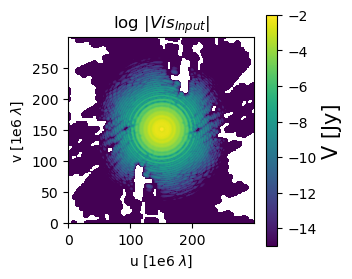

In [20]:
plt.figure(figsize = (3, 3))
plt.imshow(np.log(np.abs(vis_gridded.reshape(FT._Nx, FT._Ny))), origin='lower', vmin=-15, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$|')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

In [17]:
Plot_ = Plot(frank2d, geom)

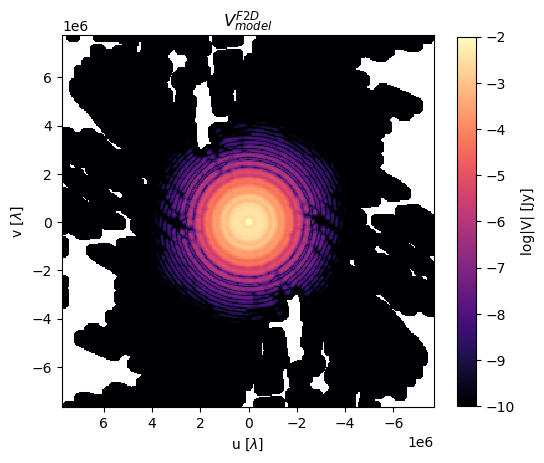

In [20]:
Plot_.visibility()

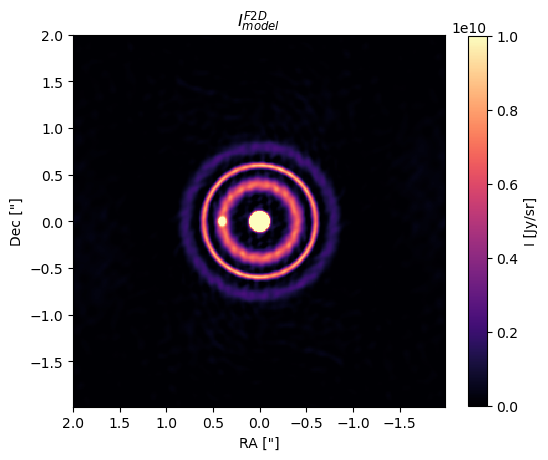

In [19]:
Plot_.intensity(vmax = 1e10, gamma = 1)

In [22]:
uvtable_cpu = {key: uvtable[key].get() for key in uvtable}

In [23]:
uvtable_gridded_cpu = {key: frank2d.gridded_data[key].get() for key in frank2d.gridded_data}

In [24]:
u_d, v_d, _ = geom.deproject(u, v)

uvtable_gridded_cpu['u'] = u_d
uvtable_gridded_cpu['v'] = v_d

In [25]:
params = {'m': best_params['m'], 'c': best_params['c']}

In [26]:
ME = MAPEstimator(frank2d._Rmax,  frank2d._Geometry)
frank2d.set_MAP_estimator(ME)

AttributeError: 'Frank2D' object has no attribute '_Geometry'

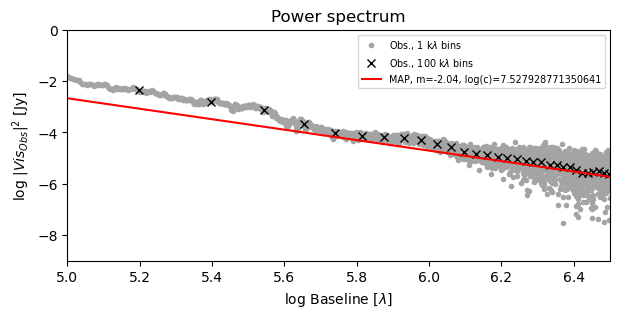

In [38]:
Plot_.MAP_power_spectrum(data = uvtable_cpu, params = params)

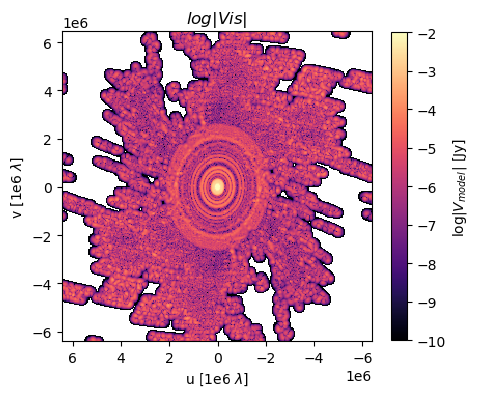

In [26]:
Plot_AS209.visibility(fig_size = 5, kind = 'model')

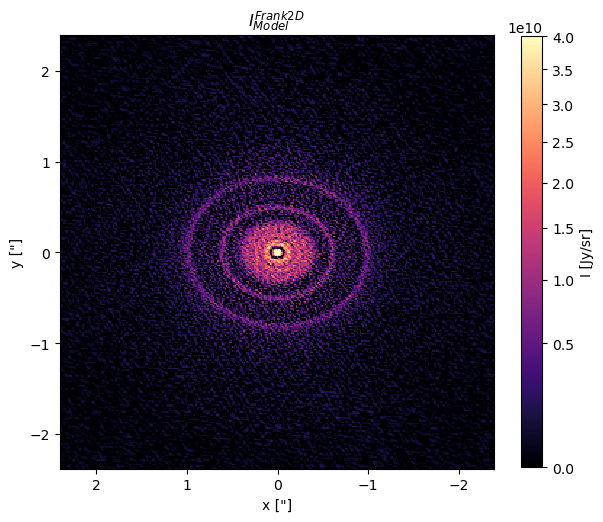

In [27]:
Plot_AS209.intensity(fig_size = 7, vmax = 4e10, gamma = 0.6, title = r'$I_{Model}^{Frank2D}$')

Performing 1D Frank fit...


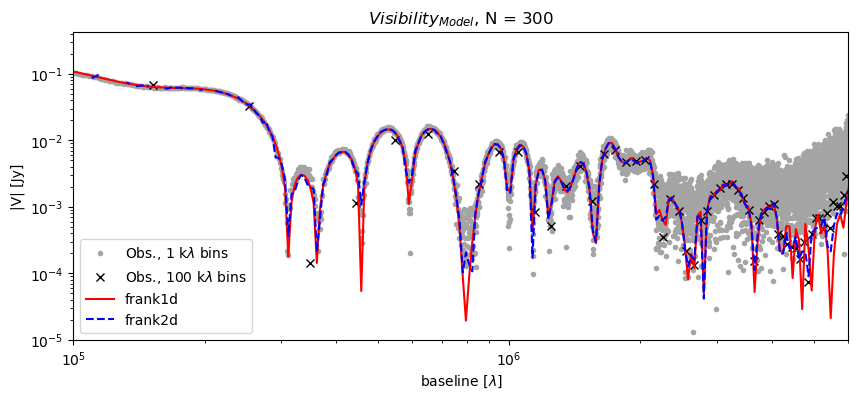

In [ ]:
Plot_AS209.visibility_profile(input = uvtable, weighted = True, frank1d = True)

Performing 1D Frank fit...


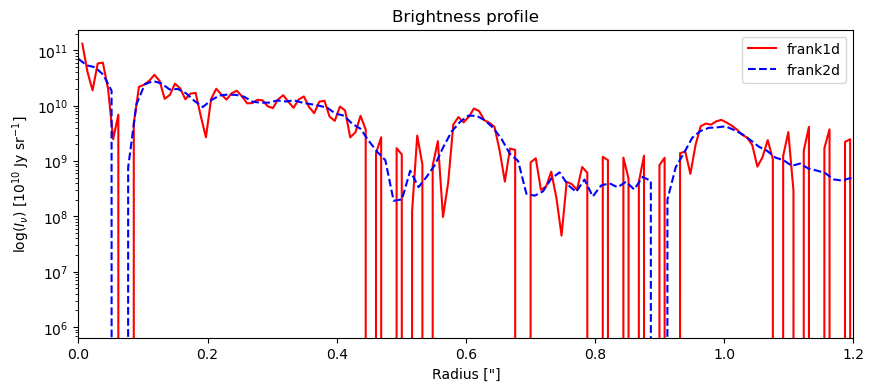

In [ ]:
Plot_AS209.intensity_profile(clean = False)

In [ ]:
dir_fits =  dir
disk_fits = disk_name + '_continuum.fits'
fits_file = dir_fits + disk_fits

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
Performing 1D Frank fit...


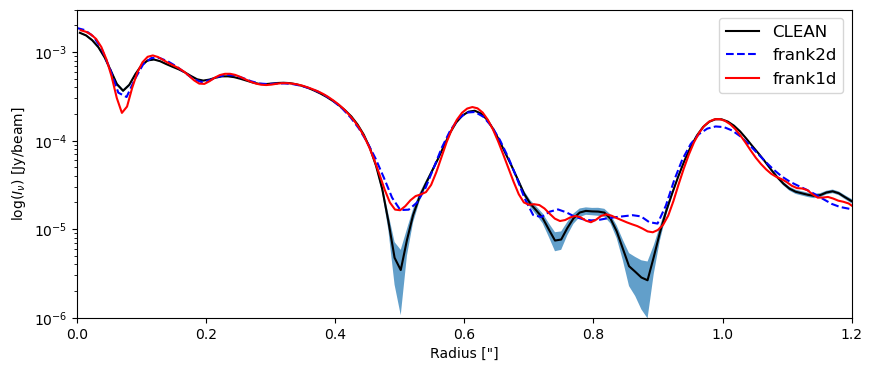

In [ ]:
Plot_AS209.intensity_profile(clean = True, fits_file = fits_file)

## Best

In [ ]:
frank2d.search_MAP()

In [ ]:
frank2d.MAP